In [23]:
import pandas as pd

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
stressLvlDf = pd.read_csv("../data/raw/StressLevelDataset.csv")

In [26]:
train_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_train_featured.csv')
test_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_test_featured.csv')

In [27]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
engineered_feature_cols = [c for c in train_df.columns if c != "target"]
print(f"{len(engineered_feature_cols)} features going into feature selection")

X_train_eng = train_df[engineered_feature_cols]
y_train_eng = train_df["target"]
X_test_eng = test_df[engineered_feature_cols]
y_test_eng = test_df["target"]

rf_selector = RandomForestClassifier(random_state=42)
rf_selector.fit(X_train_eng, y_train_eng)

importances = pd.Series(rf_selector.feature_importances_, index=engineered_feature_cols).sort_values(ascending=False)
print(importances)

24 features going into feature selection
blood_pressure                  0.109122
social_score                    0.091721
anxiety_level                   0.079242
basic_needs                     0.061528
academic_performance            0.056955
self_esteem                     0.051706
depression                      0.050660
social_support                  0.050450
physical_score                  0.049173
bullying                        0.048579
headache                        0.046502
sleep_quality                   0.043995
teacher_student_relationship    0.041525
extracurricular_activities      0.040932
safety                          0.036843
future_career_concerns          0.032621
peer_pressure                   0.031381
environment_score               0.015168
mental_health_score             0.014320
noise_level                     0.012122
living_conditions               0.011973
study_load                      0.011534
breathing_problem               0.008823
mental_health_hi

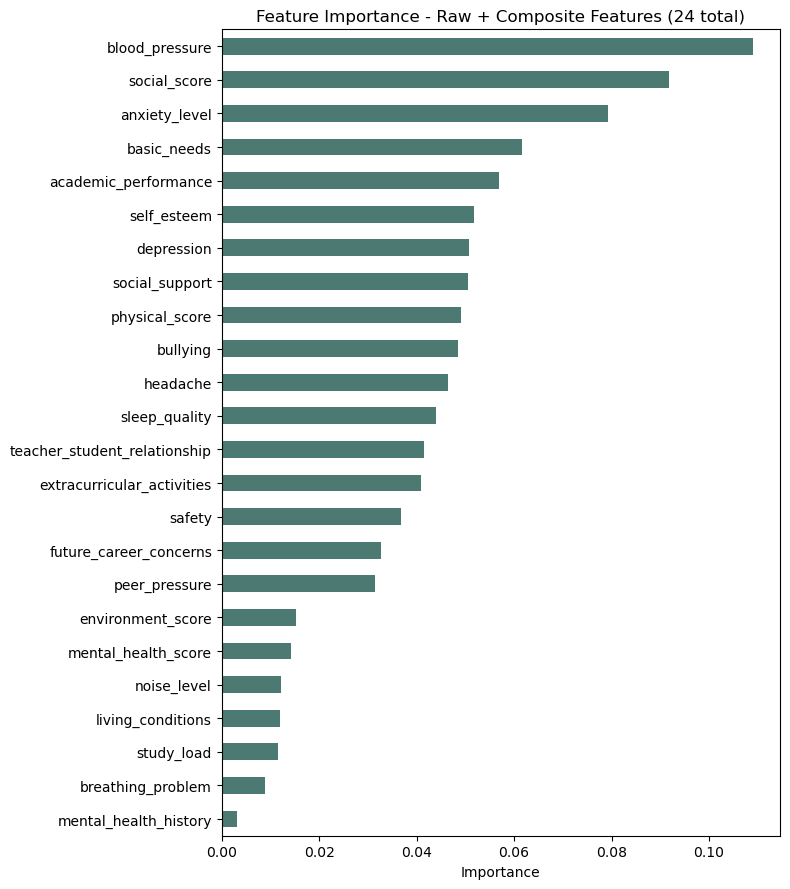

In [45]:
plt.figure(figsize=(8, 9))
importances.plot(kind='barh', color='#4C7A73')
plt.gca().invert_yaxis()
plt.title("Feature Importance - Raw + Composite Features (24 total)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../results/eda_visualizations/feature_importance_full.png", dpi=150, bbox_inches='tight')
plt.show()

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

In [31]:
#select 10 best

top10 = importances.head(10).index.tolist()
print("Top 10 selected features:", top10)

Top 10 selected features: ['blood_pressure', 'social_score', 'anxiety_level', 'basic_needs', 'academic_performance', 'self_esteem', 'depression', 'social_support', 'physical_score', 'bullying']


In [32]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []
for name, model in models.items():
    full_score = cross_val_score(model, X_train_eng, y_train_eng, cv=5, scoring='accuracy').mean()
    top10_score = cross_val_score(model, X_train_eng[top10], y_train_eng, cv=5, scoring='accuracy').mean()

    results.append({
        "Model": name,
        "Full (24 features)": full_score,
        "Top 10 features": top10_score,
        "Difference": top10_score - full_score
    })
    print(f"{name}: Full={full_score:.4f}  Top10={top10_score:.4f}  Diff={top10_score-full_score:+.4f}")

results_df = pd.DataFrame(results)

Random Forest: Full=0.8670  Top10=0.8830  Diff=+0.0159
SVM: Full=0.8739  Top10=0.8784  Diff=+0.0045
KNN: Full=0.8670  Top10=0.8705  Diff=+0.0034
Logistic Regression: Full=0.8761  Top10=0.8875  Diff=+0.0114
Naive Bayes: Full=0.8818  Top10=0.8807  Diff=-0.0011


In [33]:
#Saving

top10_train_df = train_df[top10 + ["target"]]
top10_test_df = test_df[top10 + ["target"]]

top10_train_df.to_csv("../results/outputs/Selected/train_rf_top10_features.csv", index=False)
top10_test_df.to_csv("../results/outputs/Selected/test_rf_top10_features.csv", index=False)

print("Saved train_rf_top10_features.csv:", top10_train_df.shape)
print("Saved test_rf_top10_features.csv:", top10_test_df.shape)

Saved train_rf_top10_features.csv: (880, 11)
Saved test_rf_top10_features.csv: (220, 11)


In [34]:
import joblib
joblib.dump(top10, "../results/model_trained_files/top10_features_list.pkl")

['../results/model_trained_files/top10_features_list.pkl']

In [35]:
#ANOVA F

In [36]:
from sklearn.feature_selection import SelectKBest, f_classif

In [37]:
engineered_feature_cols = [c for c in train_df.columns if c != "target"]
X_train_eng = train_df[engineered_feature_cols]
y_train_eng = train_df["target"]

# Compute F-scores and p-values
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train_eng, y_train_eng)

anova_scores = pd.Series(selector.scores_, index=engineered_feature_cols).sort_values(ascending=False)
anova_pvalues = pd.Series(selector.pvalues_, index=engineered_feature_cols)

print("ANOVA F-scores (higher = more discriminative):")
print(anova_scores)

print("\nP-values (lower = more statistically significant):")
print(anova_pvalues[anova_scores.index])

ANOVA F-scores (higher = more discriminative):
blood_pressure                  823.730390
self_esteem                     625.438459
bullying                        588.842939
sleep_quality                   568.472492
anxiety_level                   553.438806
academic_performance            552.889246
future_career_concerns          539.463866
depression                      526.697843
basic_needs                     501.338055
headache                        478.797216
safety                          467.685176
teacher_student_relationship    465.692192
peer_pressure                   457.644976
extracurricular_activities      428.039621
social_score                    425.077178
environment_score               373.860215
physical_score                  373.133042
mental_health_score             357.701677
social_support                  350.442942
noise_level                     332.712800
mental_health_history           331.076345
study_load                      307.839338
living_

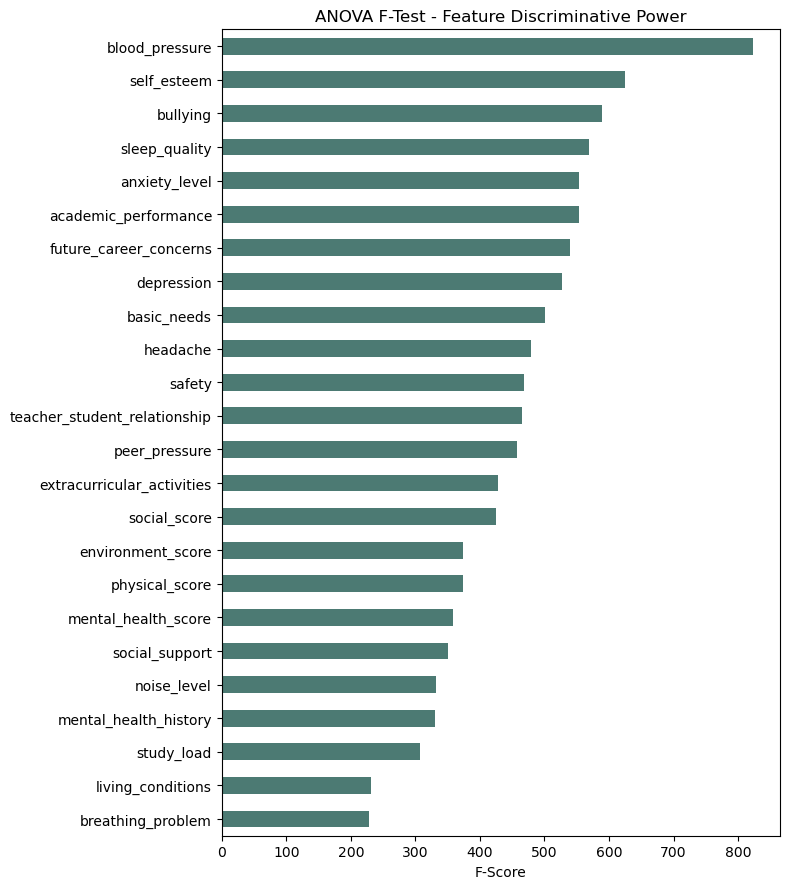

In [38]:
plt.figure(figsize=(8, 9))
anova_scores.plot(kind='barh', color='#4C7A73')
plt.gca().invert_yaxis()
plt.title("ANOVA F-Test - Feature Discriminative Power")
plt.xlabel("F-Score")
plt.tight_layout()
plt.savefig("../results/eda_visualizations/anova_f_test.png", dpi=150, bbox_inches='tight')
plt.show()

In [39]:
anova_top10 = anova_scores.head(10).index.tolist()
print("ANOVA-selected top 10:", anova_top10)

ANOVA-selected top 10: ['blood_pressure', 'self_esteem', 'bullying', 'sleep_quality', 'anxiety_level', 'academic_performance', 'future_career_concerns', 'depression', 'basic_needs', 'headache']


In [40]:
rf_top10 = importances.head(10).index.tolist()
overlap = set(anova_top10) & set(rf_top10)

print(f"ANOVA ∩ Random Forest: {len(overlap)}/10 features agree")
print(overlap)

ANOVA ∩ Random Forest: 7/10 features agree
{'bullying', 'self_esteem', 'anxiety_level', 'depression', 'academic_performance', 'basic_needs', 'blood_pressure'}


In [41]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB()
}

anova_results = []
for name, model in models.items():
    full_score = cross_val_score(model, X_train_eng, y_train_eng, cv=5, scoring='accuracy').mean()
    anova_score = cross_val_score(model, X_train_eng[anova_top10], y_train_eng, cv=5, scoring='accuracy').mean()

    anova_results.append({"Model": name, "Full (24)": full_score, "ANOVA Top 10": anova_score})
    print(f"{name}: Full={full_score:.4f}  ANOVA={anova_score:.4f}  Diff={anova_score-full_score:+.4f}")

anova_results_df = pd.DataFrame(anova_results)

Random Forest: Full=0.8670  ANOVA=0.8795  Diff=+0.0125
SVM: Full=0.8739  ANOVA=0.8807  Diff=+0.0068
KNN: Full=0.8670  ANOVA=0.8795  Diff=+0.0125
Logistic Regression: Full=0.8761  ANOVA=0.8784  Diff=+0.0023
Naive Bayes: Full=0.8818  ANOVA=0.8875  Diff=+0.0057


In [42]:
#so for random forest use the use rf one and for other models use anova top 10

In [43]:
#saving

top10_train_df_an = train_df[anova_top10 + ["target"]]
top10_test_df_an = test_df[anova_top10 + ["target"]]

top10_train_df_an.to_csv("../results/outputs/Selected/train_top10_features.csv", index=False)
top10_test_df_an.to_csv("../results/outputs/Selected/test_top10_features.csv", index=False)

print("Saved train_top10_features.csv:", top10_train_df_an.shape)
print("Saved test_top10_features.csv:", top10_test_df_an.shape)

Saved train_top10_features.csv: (880, 11)
Saved test_top10_features.csv: (220, 11)


In [46]:
import joblib
joblib.dump(anova_top10, "../results/model_trained_files/anova_top10_features.pkl")

['../results/model_trained_files/anova_top10_features.pkl']